In [1]:
import xarray as xr
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature  
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import glob
import re
import dask.array as da
from pathlib import Path


LOAD IN SITU AND GLORYS

In [2]:
out_path = '../data_for_lstm/var_depths_data_for_LSTM_B1_wg.nc'

In [3]:
ds_insitu = xr.open_dataset('../data_for_lstm/var_depths_data_for_LSTM_A2.nc',
                            decode_times=True)
ds_insitu

<xarray.Dataset> Size: 918MB
Dimensions:            (profile: 183565, depth: 102)
Coordinates:
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/19)
    LATITUDE           (profile) float64 1MB ...
    LONGITUDE          (profile) float64 1MB ...
    TIME               (profile) datetime64[ns] 1MB ...
    TEMP               (profile, depth) float64 150MB ...
    PSAL               (profile, depth) float64 150MB ...
    PRES               (profile, depth) float64 150MB ...
    ...                 ...
    Y_EASE             (profile) float64 1MB ...
    SST_glorys         (profile) float64 1MB ...
    SSS_glorys         (profile) float64 1MB ...
    ADT                (profile) float64 1MB ...
    SST                (profile) float64 1MB ...
    SSS                (profile) float64 1MB ...
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

In [4]:
# Build a dict: pd.Timestamp (date only) → Path, for all daily GLORYS files
GLORYS_ROOT = Path('/media/nicolas/DATOS/Reanalysis/GLORYS_daily_arctic_ST_2010_2024')

date_to_path = {}
for nc_file in sorted(GLORYS_ROOT.glob('**/*_float32Comp.nc')):
    m = re.search(r'(\d{4}-\d{2}-\d{2})_float32Comp', nc_file.name)
    if m:
        date_to_path[pd.Timestamp(m.group(1))] = nc_file

print(f"Found {len(date_to_path)} daily GLORYS files")
print(f"Date range: {min(date_to_path)} to {max(date_to_path)}")


Found 5479 daily GLORYS files
Date range: 2010-01-01 00:00:00 to 2024-12-31 00:00:00


BUILD GLORYS PROFILES (daily, day by day)

A significative percentage of these columns/profiles that we extract from GLORYS dataset might fall short in depth coverage comparing to the in situ profile (when the instrument went below the glorys coverage). But this is no problem, since the training script will be working on the difference between those, and when doing such a difference nans will appear at the shortest depth.

In [5]:
def interp_to_insitu_depths(glorys_vals, glorys_depths, insitu_depths):
    """
    Interpolate one GLORYS profile from its 50 native levels to insitu_depths.
    - Filters NaN levels first
    - Linear interpolation within the valid GLORYS depth range (np.interp)
    - Linear extrapolation at the surface (upward only, using first two valid levels)
    - NaN where insitu depth exceeds the deepest valid GLORYS level (no deep extrapolation)
    """
    valid = ~np.isnan(glorys_vals)
    if valid.sum() < 2:
        return np.full(len(insitu_depths), np.nan)
    gd = glorys_depths[valid]
    gv = glorys_vals[valid]

    result = np.interp(insitu_depths, gd, gv, left=np.nan, right=np.nan)

    # Surface-only linear extrapolation using first two valid GLORYS levels
    surface_mask = insitu_depths < gd[0]
    if np.any(surface_mask):
        slope = (gv[1] - gv[0]) / (gd[1] - gd[0])
        result[surface_mask] = gv[0] + slope * (insitu_depths[surface_mask] - gd[0])

    return result


# 5x5 spatial window offsets sorted by distance from centre (same as JN_A1)
OFFSETS_5X5 = [
    (1, 0), (-1, 0), (0, 1), (0, -1),
    (1, 1), (1, -1), (-1, 1), (-1, -1),
    (2, 0), (-2, 0), (0, 2), (0, -2),
    (2, 1), (2, -1), (-2, 1), (-2, -1), (1, 2), (1, -2), (-1, 2), (-1, -2),
    (2, 2), (2, -2), (-2, 2), (-2, -2)
]

def get_glorys_column_with_window(data_np, lat_grid, lon_grid, lat_val, lon_val):
    """
    Extract a depth column from data_np (depth, lat, lon) at the nearest grid point.
    If that point is all-NaN (land/ice), search within the 5x5 window.
    Longitude wraps around (global grid). Returns all-NaN if nothing found.
    """
    i_lat = int(np.argmin(np.abs(lat_grid - lat_val)))
    i_lon = int(np.argmin(np.abs(lon_grid - lon_val)))
    n_lat, n_lon = len(lat_grid), len(lon_grid)

    col = data_np[:, i_lat, i_lon]
    if not np.all(np.isnan(col)):
        return col

    for d_lat, d_lon in OFFSETS_5X5:
        ni_lat = i_lat + d_lat
        ni_lon = (i_lon + d_lon) % n_lon   # wrap longitude globally
        if 0 <= ni_lat < n_lat:
            col = data_np[:, ni_lat, ni_lon]
            if not np.all(np.isnan(col)):
                return col

    return np.full(data_np.shape[0], np.nan)


# Pre-allocate output arrays
n_profiles = len(ds_insitu['profile'])
insitu_depths = ds_insitu['depth'].values
n_insitu_depths = len(insitu_depths)

nearest_S_np = np.full((n_profiles, n_insitu_depths), np.nan)
nearest_T_np = np.full((n_profiles, n_insitu_depths), np.nan)


In [6]:
import warnings
from tqdm.notebook import tqdm

# Group in-situ profile indices by calendar date (floored to midnight)
times_pd = pd.DatetimeIndex(ds_insitu['TIME'].values)
insitu_dates = times_pd.normalize()                          # DatetimeIndex, midnight
unique_insitu_dates = sorted(set(insitu_dates))              # list of pd.Timestamp
n_unique = len(unique_insitu_dates)

glorys_depths = None   # will be set on first loaded file
missing_glorys_days = []
n_debug = 5   # number of profiles to print diagnostics for
n_debug_done = 0
n_allnan_total = 0   # cumulative all-NaN columns across all days

for i_day, insitu_date in enumerate(tqdm(unique_insitu_dates, desc='GLORYS days')):

    # indices of all profiles for this calendar day
    prof_indices = np.where(insitu_dates == insitu_date)[0]

    # --- Guard: no GLORYS file for this day ---
    if insitu_date not in date_to_path:
        missing_glorys_days.append(insitu_date)
        warnings.warn(f"No GLORYS file for {insitu_date.date()}: "
                      f"{len(prof_indices)} profiles will remain NaN")
        continue

    ds_central = xr.open_dataset(date_to_path[insitu_date]).isel(time=0).compute()

    if glorys_depths is None:
        glorys_depths = ds_central['depth'].values

    # Load numpy arrays for fast indexing
    so_np     = ds_central['so'].values      # (depth, lat, lon)
    thetao_np = ds_central['thetao'].values
    lat_grid  = ds_central['latitude'].values
    lon_grid  = ds_central['longitude'].values
    ds_central.close()

    lats_vals = ds_insitu['LATITUDE'].values[prof_indices]
    lons_vals  = ds_insitu['LONGITUDE'].values[prof_indices]
    n_day = len(prof_indices)

    S_at_glorys = np.full((n_day, len(glorys_depths)), np.nan)
    T_at_glorys = np.full((n_day, len(glorys_depths)), np.nan)

    # ----- Step 1: nearest-neighbour extraction with 5x5 window fallback -----
    for j in range(n_day):
        S_at_glorys[j] = get_glorys_column_with_window(so_np, lat_grid, lon_grid,
                                                        lats_vals[j], lons_vals[j])
        T_at_glorys[j] = get_glorys_column_with_window(thetao_np, lat_grid, lon_grid,
                                                        lats_vals[j], lons_vals[j])

    # Count all-NaN columns for this day (use S; T should match)
    n_allnan_day = int(np.sum(np.all(np.isnan(S_at_glorys), axis=1)))
    n_allnan_total += n_allnan_day

    # ----- Every 100 days: report cumulative all-NaN column count -----
    if (i_day + 1) % 100 == 0:
        print(f"  [Day {i_day + 1:4d}/{n_unique}] cumulative all-NaN GLORYS columns: {n_allnan_total}")

    # ----- Step 2: depth interpolation to in-situ levels -----
    for j, prof_i in enumerate(prof_indices):
        nearest_S_np[prof_i] = interp_to_insitu_depths(S_at_glorys[j], glorys_depths, insitu_depths)
        nearest_T_np[prof_i] = interp_to_insitu_depths(T_at_glorys[j], glorys_depths, insitu_depths)

        # ----- Debug: print avg difference for first n_debug profiles -----
        if n_debug_done < n_debug:
            t_insitu = ds_insitu['TEMP'].values[prof_i]
            s_insitu = ds_insitu['PSAL'].values[prof_i]
            t_glorys = nearest_T_np[prof_i]
            s_glorys = nearest_S_np[prof_i]

            valid_T = ~np.isnan(t_insitu) & ~np.isnan(t_glorys)
            valid_S = ~np.isnan(s_insitu) & ~np.isnan(s_glorys)
            mean_dT = np.mean(t_glorys[valid_T] - t_insitu[valid_T]) if valid_T.any() else np.nan
            mean_dS = np.mean(s_glorys[valid_S] - s_insitu[valid_S]) if valid_S.any() else np.nan

            print(f"  Profile {prof_i:6d} | lat={lats_vals[j]:6.2f} lon={lons_vals[j]:7.2f} | "
                  f"mean(T_glorys-T_insitu)={mean_dT:+.3f}°C  "
                  f"mean(S_glorys-S_insitu)={mean_dS:+.3f} PSU  "
                  f"[valid T levels: {valid_T.sum()}, valid S levels: {valid_S.sum()}]")
            n_debug_done += 1

print(f"\nDone!")
print(f"  Days with no GLORYS file: {len(missing_glorys_days)}")
if missing_glorys_days:
    shown = [str(d.date()) for d in missing_glorys_days[:5]]
    print(f"  Missing days: {shown}{'...' if len(missing_glorys_days) > 5 else ''}")
print(f"  Total all-NaN GLORYS columns (across all days): {n_allnan_total}")


GLORYS days:   0%|          | 0/4017 [00:00<?, ?it/s]

  Profile      0 | lat= 78.37 lon=-149.93 | mean(T_glorys-T_insitu)=-0.091°C  mean(S_glorys-S_insitu)=+0.235 PSU  [valid T levels: 82, valid S levels: 82]
  Profile      1 | lat= 77.89 lon=  11.29 | mean(T_glorys-T_insitu)=+0.548°C  mean(S_glorys-S_insitu)=+0.267 PSU  [valid T levels: 22, valid S levels: 22]
  Profile      2 | lat= 78.43 lon=  10.11 | mean(T_glorys-T_insitu)=+1.538°C  mean(S_glorys-S_insitu)=+0.062 PSU  [valid T levels: 23, valid S levels: 23]
  Profile      3 | lat= 73.87 lon=  -4.65 | mean(T_glorys-T_insitu)=-0.054°C  mean(S_glorys-S_insitu)=+0.004 PSU  [valid T levels: 79, valid S levels: 79]
  Profile      4 | lat= 79.84 lon=  10.80 | mean(T_glorys-T_insitu)=+0.774°C  mean(S_glorys-S_insitu)=+0.238 PSU  [valid T levels: 10, valid S levels: 10]
  [Day  100/4017] cumulative all-NaN GLORYS columns: 0
  [Day  200/4017] cumulative all-NaN GLORYS columns: 0
  [Day  300/4017] cumulative all-NaN GLORYS columns: 0
  [Day  400/4017] cumulative all-NaN GLORYS columns: 0
  [Da

--------------------------------
--------------------------------

Add S_glorys_filled and T_glorys_filled to the insitu dataset

In [7]:
ds_insitu['S_glorys'] = xr.DataArray(nearest_S_np, dims=('profile', 'depth'),
                         attrs={
                             'long_name': 'GLORYS salinity',
                             'units': '1',
                             'description': 'Interpolated from nearest GLORYS, with 5x5 window search and depth linear interpolation'
                         })
ds_insitu['T_glorys'] = xr.DataArray(nearest_T_np, dims=('profile', 'depth'),
                         attrs={
                             'long_name': 'GLORYS temperature',
                             'units': 'degree_Celsius',
                             'description': 'Interpolated from nearest GLORYS, with 5x5 window search and depth linear interpolation'
                         })


In [8]:
ds_insitu

<xarray.Dataset> Size: 1GB
Dimensions:            (profile: 183565, depth: 102)
Coordinates:
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/21)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 150MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 150MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 150MB ...
    ...                 ...
    SSS_glorys         (profile) float64 1MB ...
    ADT                (profile) float64 1MB ...
    SST                (profile) float64 1MB ...
    SSS                (profile) float64 1MB ...
    S_glorys           (profile, depth) float64 150MB 29.97 29.97 ... nan nan
    T_glorys           (profile, depth) float64 150MB -1.596 -1.596 ... nan nan
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

-----------------------
----------------------

But... some checks

---------------------------
---------------------------

this should be true:

In [ ]:
np.all(np.isnan(ds_insitu.S_glorys.values) == np.isnan(ds_insitu.T_glorys.values))

np.True_

Let's see if there are the empty profiles

In [11]:
mask = np.all(np.isnan(ds_insitu.T_glorys.values), axis=1)
print(np.sum(mask))
print(len(mask))

0
183565


if there are not, save it

In [12]:
ds_insitu.to_netcdf(out_path)

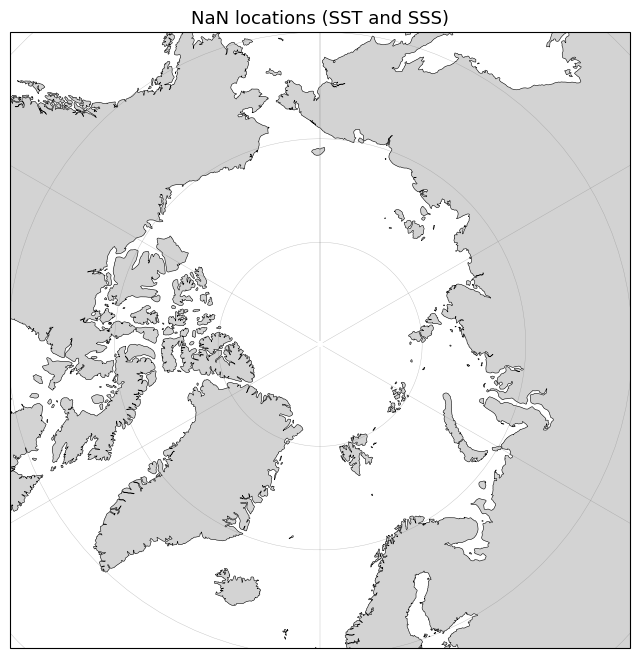

In [13]:
# Create figure with Arctic projection
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

#THis should show very little profiles,
# only where there is no coverage from glorys or aviso

x_vals = ds_insitu['LONGITUDE'].values[mask]
y_vals = ds_insitu['LATITUDE'].values[mask]

# Limit to Arctic region
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

# Scatter colored by year 
sc = ax.scatter(
    x_vals,
    y_vals,
    #c=ds_insitu['TEMP'].isel(depth=0).values,
    s=0.5,
    c='darkblue', 
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

plt.title("NaN locations (SST and SSS)", fontsize=13)
plt.show()
#plt.savefig("Insitu_profile_salinity.png", dpi=350)

If it's only coastal, let's discard them

In [14]:
ds_insitu_clean = ds_insitu.isel(profile=~mask)
ds_insitu_clean = ds_insitu_clean.assign_coords(profile=np.arange(len(ds_insitu_clean['profile'])))
print( f'last profile index: {ds_insitu_clean.profile.values[-1]}')

last profile index: 183564


In [15]:
ds_insitu_clean

<xarray.Dataset> Size: 1GB
Dimensions:            (profile: 183565, depth: 102)
Coordinates:
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/21)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 150MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 150MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 150MB ...
    ...                 ...
    SSS_glorys         (profile) float64 1MB ...
    ADT                (profile) float64 1MB ...
    SST                (profile) float64 1MB ...
    SSS                (profile) float64 1MB ...
    S_glorys           (profile, depth) float64 150MB 29.97 29.97 ... nan nan
    T_glorys           (profile, depth) float64 150MB -1.596 -1.596 ... nan nan
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

---
---
### save it

In [80]:
ds_insitu_clean.to_netcdf(out_path)

---
---
### plot some profiles

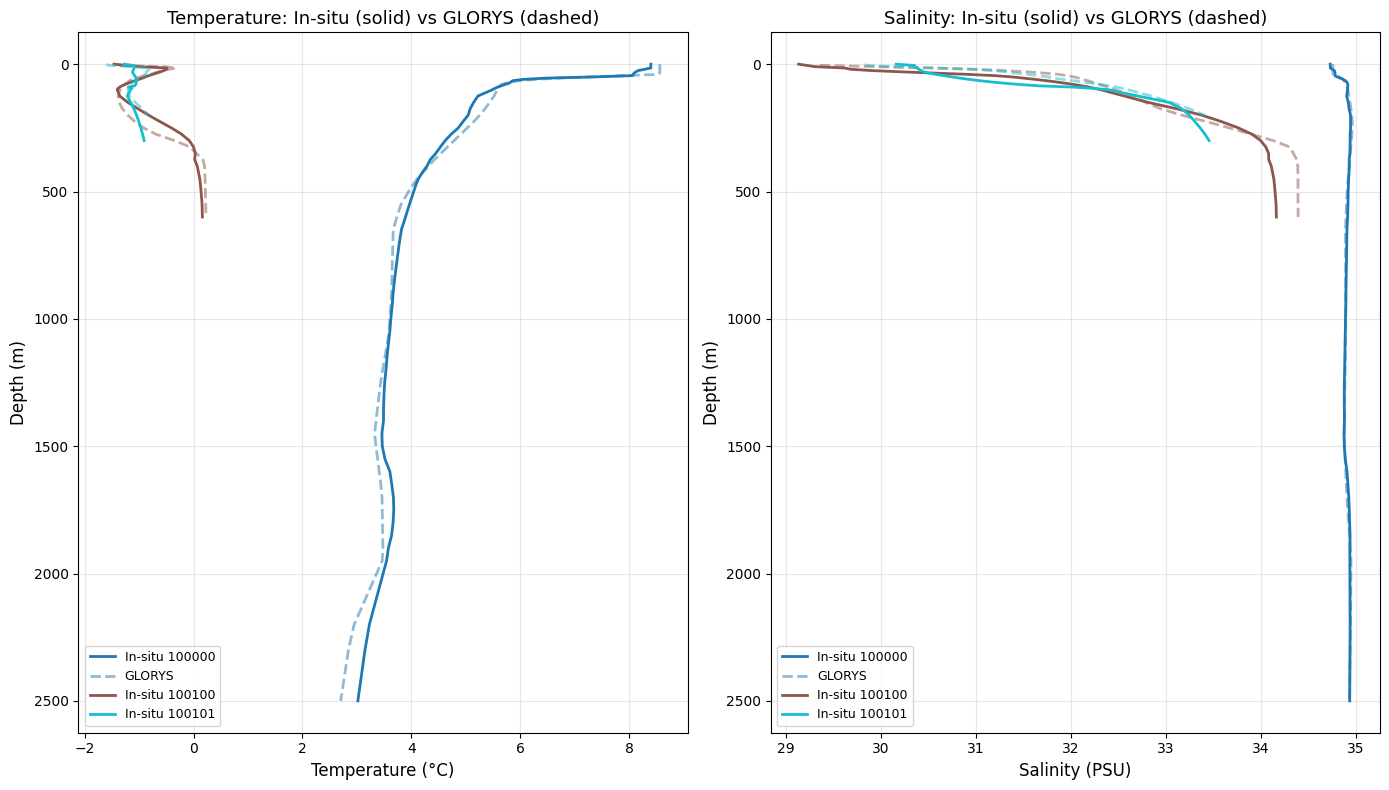

In [16]:
# Plot comparison of in-situ vs GLORYS profiles
n_profiles = 1  # Adjust number of random profiles to plot
'''
# Select random profiles
np.random.seed(42)  # For reproducibility
random_indices = np.random.choice(len(ds_insitu['profile']), size=n_profiles, replace=False)
'''
random_indices = [100000,100100,100101]
n_profiles = len(random_indices)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Color map for profiles
colors = plt.cm.tab10(np.linspace(0, 1, n_profiles))

# Plot Temperature profiles (left)
for i, prof_idx in enumerate(random_indices):
    depth = ds_insitu_clean['depth'].values
    
    # Get in-situ Temperature
    temp_insitu = ds_insitu_clean['TEMP'].isel(profile=prof_idx).values
    temp_glorys = ds_insitu_clean['T_glorys'].isel(profile=prof_idx).values
    
    # Mask GLORYS data where in-situ is NaN
    valid_mask = ~np.isnan(temp_insitu)
    
    # In-situ Temperature (solid line)
    ax1.plot(temp_insitu[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, label=f'In-situ {prof_idx}')
    
    # GLORYS Temperature (transparent line, only where in-situ has data)
    glorys_label = 'GLORYS' if i == 0 else None
    ax1.plot(temp_glorys[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, alpha=0.5, linestyle='--', label=glorys_label)

ax1.invert_yaxis()
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_title('Temperature: In-situ (solid) vs GLORYS (dashed)', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='best')

# Plot Salinity profiles (right)
for i, prof_idx in enumerate(random_indices):
    depth = ds_insitu_clean['depth'].values
    
    # Get in-situ Salinity
    psal_insitu = ds_insitu_clean['PSAL'].isel(profile=prof_idx).values
    psal_glorys = ds_insitu_clean['S_glorys'].isel(profile=prof_idx).values
    
    # Mask GLORYS data where in-situ is NaN
    valid_mask = ~np.isnan(psal_insitu)
    
    # In-situ Salinity (solid line)
    ax2.plot(psal_insitu[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, label=f'In-situ {prof_idx}')
    
    # GLORYS Salinity (transparent line, only where in-situ has data)
    glorys_label = 'GLORYS' if i == 0 else None
    ax2.plot(psal_glorys[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, alpha=0.5, linestyle='--', label=glorys_label)

ax2.invert_yaxis()
ax2.set_xlabel('Salinity (PSU)', fontsize=12)
ax2.set_ylabel('Depth (m)', fontsize=12)
ax2.set_title('Salinity: In-situ (solid) vs GLORYS (dashed)', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.show()

In [17]:
ds_insitu_clean

<xarray.Dataset> Size: 1GB
Dimensions:            (profile: 183565, depth: 102)
Coordinates:
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/21)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 150MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 150MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 150MB ...
    ...                 ...
    SSS_glorys         (profile) float64 1MB ...
    ADT                (profile) float64 1MB ...
    SST                (profile) float64 1MB ...
    SSS                (profile) float64 1MB ...
    S_glorys           (profile, depth) float64 150MB 29.97 29.97 ... nan nan
    T_glorys           (profile, depth) float64 150MB -1.596 -1.596 ... nan nan
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...